### **Phase 1: Data Preparation and Exploratory Analysis (Revised)**

* **Data Loading:** Use `pandas.read_csv()` to load your dataset of 72 patients and 7,129 gene probes.
* **Binary Target Engineering:** Create a new binary target column. Map both `allB` and `allT` to `0` (representing ALL), and map `aml` to `1` (representing AML).
* **Standardization:** Apply `sklearn.preprocessing.StandardScaler` to the gene expression features to center the data (mean of 0) and scale it to unit variance (standard deviation of 1). *Note: Ensure you fit the scaler strictly on your training data to prevent data leakage, then transform both train and test sets.*
* **Dimensionality Reduction:** Fit `sklearn.decomposition.PCA` on the **scaled** data to compress the 7,129 features into 2 or 3 principal components.
* **Visualization:** Plot the PCA components using `matplotlib` or `seaborn`, coloring the points by the binary target (ALL vs. AML) to visually assess if the two main cancer types naturally separate in lower-dimensional space.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# plt.style.use('ggplot')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib_venn import venn2


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from sklearn.utils import resample
from collections import Counter

from sklearn.svm import SVC
from sklearn.feature_selection import RFECV
from mrmr import mrmr_classif

from matplotlib_venn import venn3
from IPython.display import display

In [14]:
raw_df = pd.read_csv("golub.csv", index_col=0).copy()
label_map = {"allB": 0, "allT": 0, "aml": 1}
raw_df["target"] = raw_df["cancer"].map(label_map)

metadata_cols = ["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"]
feature_cols = [column for column in raw_df.columns if column not in metadata_cols]
X = raw_df[feature_cols]
y = raw_df["target"]

print("Raw data shape:", raw_df.shape)
print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
raw_df[["cancer", "target"]].head()

# df = pd.read_csv("golub.csv").copy()
# df["target"] = df["cancer"].map({"allB": 0, "allT": 0, "aml": 1})
# df.head()
# # df = df.drop(columns=["Samples", "tissue.mf", "cancer"])
# # df.head()

Raw data shape: (72, 7135)
Feature matrix shape: (72, 7129)
Target distribution:
target
0    47
1    25
Name: count, dtype: int64


,cancer,target
Samples,,
39,allB,0
40,allB,0
42,allB,0
47,allB,0
48,allB,0


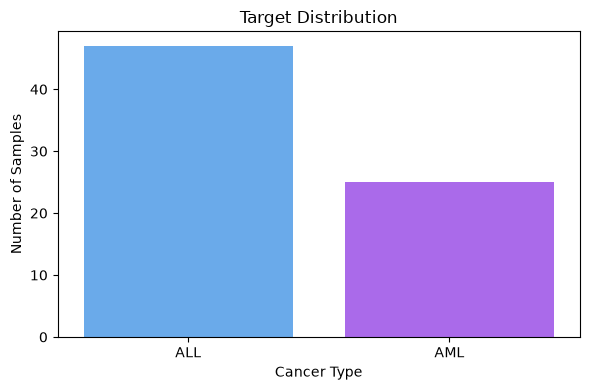

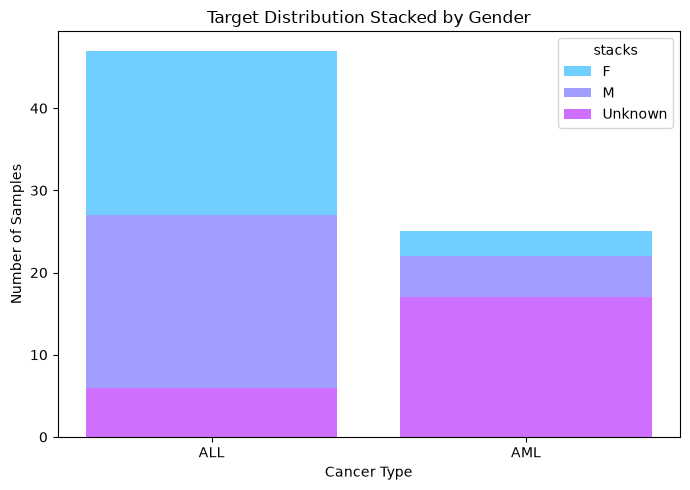

In [15]:
# Graph 1: target distribution
def plot_target_distribution(y):
    plt.figure(figsize=(6, 4))
    sns.countplot(
        x=y.map({0: "ALL", 1: "AML"}),
        hue=y.map({0: "ALL", 1: "AML"}),
        palette="cool",
        legend=False
    )
    plt.xlabel("Cancer Type")
    plt.ylabel("Number of Samples")
    plt.title("Target Distribution")
    plt.tight_layout()
    plt.show()

plot_target_distribution(y)


def plot_target_distribution_stacked(y, stacks, hue_labels):
    plot_df = pd.DataFrame({
        "target_label": y.map({0: "ALL", 1: "AML"}),
        "stacks": stacks.fillna("Unknown") if hasattr(stacks, "fillna") else stacks
    })

    plt.figure(figsize=(7, 5))
    ax = sns.histplot(
        data=plot_df,
        x="target_label",
        hue="stacks",
        multiple="stack",
        edgecolor="none",
        linewidth=0,
        shrink=0.8,
        palette="cool",
    )
    ax.set_xlabel("Cancer Type")
    ax.set_ylabel("Number of Samples")
    ax.set_title(f"Target Distribution Stacked by {hue_labels}")
    plt.tight_layout()
    plt.show()

plot_target_distribution_stacked(y, raw_df["Gender"], "Gender")

# # Graph 2: stacked bar chart
# plot_df = raw_df.copy()
# plot_df["target_label"] = plot_df["target"].map({0: "ALL", 1: "AML"})
# plot_df["Gender"] = plot_df["Gender"].fillna("Unknown")

# plt.figure(figsize=(7, 5))
# ax = sns.histplot(
#     data=plot_df,
#     x="target_label",
#     hue="Gender",
#     multiple="stack",
#     edgecolor="none",
#     linewidth=0,
#     shrink=0.8,
#     palette="cool",
# )
# ax.set_xlabel("Cancer Type")
# ax.set_ylabel("Number of Samples")
# ax.set_title("Target Distribution Stacked by Gender")
# plt.tight_layout()
# plt.show()

# # Graph 2: stacked bars with target on x-axis and stacks by gender
# plot_df = raw_df.copy()
# plot_df["target_label"] = plot_df["target"].map({0: "ALL", 1: "AML"})
# plot_df["Gender"] = plot_df["Gender"].fillna("Unknown")

# target_gender_counts = pd.crosstab(plot_df["target_label"], plot_df["Gender"])
# ax = target_gender_counts.plot(kind="bar", stacked=True, figsize=(7, 5), colormap="Set2")
# ax.set_xlabel("Cancer Type")
# ax.set_ylabel("Number of Samples")
# ax.set_title("Target Distribution Stacked by Gender")
# ax.legend(title="Gender")
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()


In [16]:
# split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# plot_target_distribution(y_train)
# plot_target_distribution(y_test)
# plot_target_distribution_stacked(y_train, raw_df.loc[y_train.index, "Gender"], "Gender (Training Set)")
# plot_target_distribution_stacked(y_test, raw_df.loc[y_test.index, "Gender"], "Gender (Testing Set)")

In [17]:
# scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


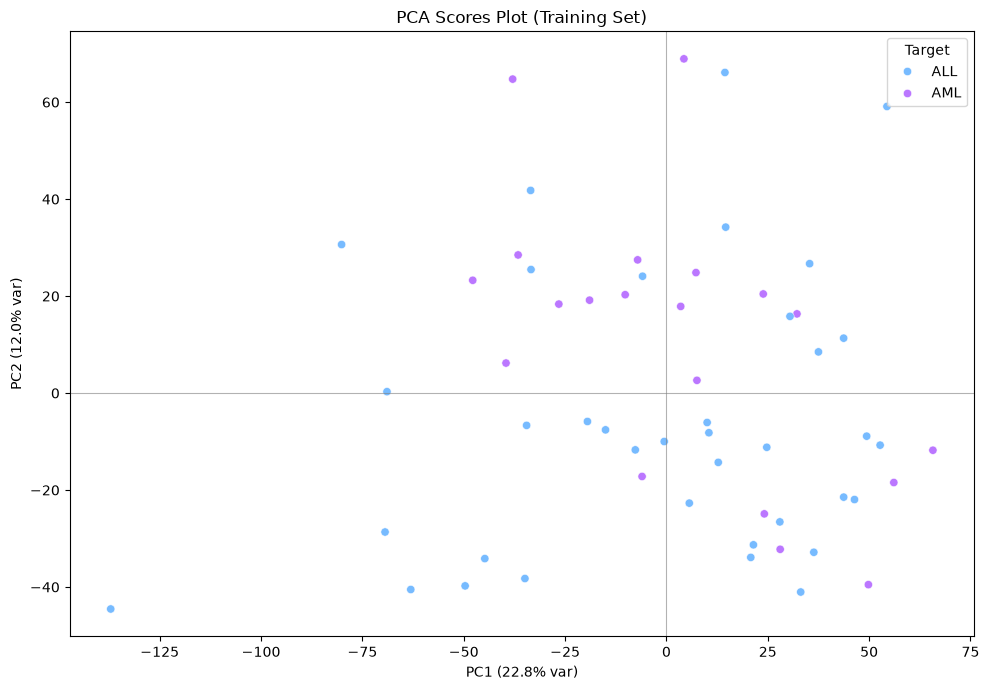

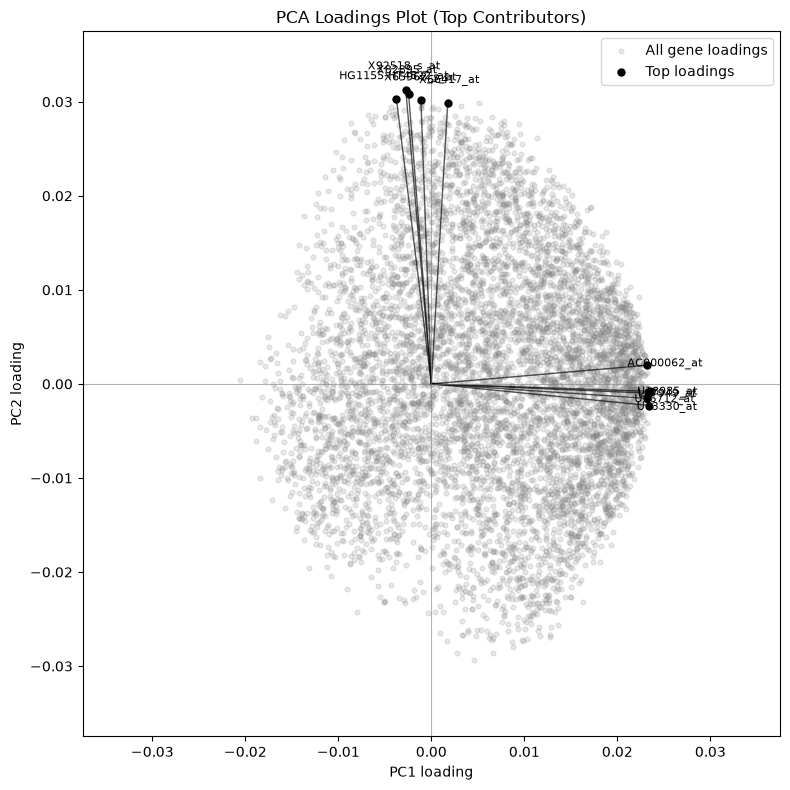

In [18]:
# run PCA on the training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

def plot_pca_two_views(scores, pca_model, y_labels, feature_names, top_per_pc=5):
    # Plot 1: sample scores in PC space
    plot_df = pd.DataFrame({
        "PC1": scores[:, 0],
        "PC2": scores[:, 1],
        "target": y_labels.map({0: "ALL", 1: "AML"}) if hasattr(y_labels, "map") else y_labels
    })

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(
        data=plot_df,
        x="PC1",
        y="PC2",
        hue="target",
        palette="cool",
        alpha=0.8,
        ax=ax
    )
    explained = pca_model.explained_variance_ratio_ * 100
    ax.set_xlabel(f"PC1 ({explained[0]:.1f}% var)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1f}% var)")
    ax.set_title("PCA Scores Plot (Training Set)")
    ax.axhline(0, color="gray", linewidth=0.8, alpha=0.6)
    ax.axvline(0, color="gray", linewidth=0.8, alpha=0.6)
    ax.legend(title="Target")
    plt.tight_layout()
    plt.show()

    # Plot 2: loading vectors in PC space
    loadings = pca_model.components_.T
    idx_pc1 = np.argsort(np.abs(loadings[:, 0]))[-top_per_pc:]
    idx_pc2 = np.argsort(np.abs(loadings[:, 1]))[-top_per_pc:]
    top_idx = np.unique(np.concatenate([idx_pc1, idx_pc2]))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(loadings[:, 0], loadings[:, 1], s=12, alpha=0.18, color="gray", label="All gene loadings")
    ax.scatter(loadings[top_idx, 0], loadings[top_idx, 1], s=25, color="black", label="Top loadings")

    for idx in top_idx:
        x_val, y_val = loadings[idx, 0], loadings[idx, 1]
        ax.plot([0, x_val], [0, y_val], color="black", alpha=0.65, linewidth=1)
        ax.text(x_val * 1.08, y_val * 1.08, feature_names[idx], fontsize=8, ha="center", va="center")

    lim = np.max(np.abs(loadings[:, :2])) * 1.2
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("PC1 loading")
    ax.set_ylabel("PC2 loading")
    ax.set_title("PCA Loadings Plot (Top Contributors)")
    ax.axhline(0, color="gray", linewidth=0.8, alpha=0.6)
    ax.axvline(0, color="gray", linewidth=0.8, alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_pca_two_views(
    scores=X_train_pca,
    pca_model=pca,
    y_labels=y_train,
    feature_names=feature_cols,
    top_per_pc=5
)

### **Phase 2: Statistical Significance (Control of False Discoveries)**

* **Univariate Analysis:** Since you now have two groups (ALL vs. AML), loop through all 7,129 genes and perform a two-sample statistical test for each (e.g., Welch's t-test using `scipy.stats.ttest_ind` with `equal_var=False`, or the non-parametric Mann-Whitney U test using `scipy.stats.mannwhitneyu`).
* **Multiple Testing Correction:** Extract the 7,129 p-values and pass them through `statsmodels.stats.multitest.multipletests` using `method='fdr_bh'` to compute the False Discovery Rate (FDR).
* **Baseline Output:** Save the list of genes that pass your FDR threshold (e.g., FDR < 0.05). This is your statistically significant baseline.

In [19]:
# Separate the training data into ALL (0) and AML (1) groups
# y_train is a pandas Series, so we use its values to index the X_train NumPy array
X_train_ALL = X_train[y_train.values == 0]
X_train_AML = X_train[y_train.values == 1]

# Perform Univariate Analysis (Welch's t-test)
# We use equal_var=False because we cannot assume the variance of gene expression is identical between the ALL and AML groups. axis=0 runs the test across all columns (genes).
t_stats, p_values = ttest_ind(X_train_ALL, X_train_AML, equal_var=False, axis=0)

# Multiple Testing Correction (FDR using Benjamini-Hochberg)
# We set alpha to 0.05 to control the False Discovery Rate at 5%
reject_null, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Compile the results into a structured DataFrame for easy viewing
ttest_results = pd.DataFrame({
    'Gene_Probe': feature_cols,
    'T_Statistic': t_stats,
    'Raw_P_Value': p_values,
    'FDR_Corrected_P': pvals_corrected,
    'Is_Significant': reject_null
})

# Sort the genes from most to least significant
ttest_results = ttest_results.sort_values(by='FDR_Corrected_P', ascending=True)

# Extract the final baseline list of statistically significant genes
significant_genes = ttest_results[ttest_results['Is_Significant']]['Gene_Probe'].tolist()

# Output the detailed account of conclusions
print(f"--- Statistical Significance ---")
print(f"Total gene probes tested: {len(feature_cols)}")
print(f"Number of statistically significant genes (FDR < 0.05): {len(significant_genes)}")
print(f"Percentage of genes considered significant: {(len(significant_genes)/len(feature_cols))*100:.2f}%\n")

print("Top 50 most significant gene probes:")
print(ttest_results.head(50))



--- Statistical Significance ---
Total gene probes tested: 7129
Number of statistically significant genes (FDR < 0.05): 663
Percentage of genes considered significant: 9.30%

Top 50 most significant gene probes:
            Gene_Probe  T_Statistic   Raw_P_Value  FDR_Corrected_P  \
6280       M31211_s_at     7.761132  2.779597e-10     9.504358e-07   
4972         Y08612_at     7.618312  3.999589e-10     9.504358e-07   
2440         S50223_at     7.877414  1.389871e-10     9.504358e-07   
6854         M31523_at     8.049950  7.453702e-10     1.328436e-06   
6701  X97267_rna1_s_at     7.418268  1.484773e-09     2.116989e-06   
4327         X59417_at     7.564360  1.930606e-09     2.293882e-06   
2353         M92287_at     7.474291  4.138337e-09     4.214601e-06   
2641    U05259_rna1_at     7.415155  6.678569e-09     5.951439e-06   
1143         J05243_at     6.930218  1.036493e-08     8.210175e-06   
3721         U77948_at     6.741875  1.330184e-08     9.482885e-06   
803   HG1612-HT161

In [20]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Separate the training data into ALL (0) and AML (1) groups
X_train_ALL = X_train[y_train == 0]
X_train_AML = X_train[y_train == 1]

# ==========================================
# TEST 1: Parametric (Welch's T-Test)
# ==========================================
# Run Welch's t-test across all genes simultaneously using axis=0
t_stats, p_values_t = ttest_ind(X_train_ALL, X_train_AML, equal_var=False, axis=0)

# Apply Benjamini-Hochberg FDR correction (alpha = 0.05)
reject_null_t, pvals_corrected_t, _, _ = multipletests(p_values_t, alpha=0.05, method='fdr_bh')

# Extract significant genes based on the t-test
sig_genes_t = [feature_cols[i] for i in range(len(feature_cols)) if reject_null_t[i]]


# ==========================================
# TEST 2: Non-Parametric (Mann-Whitney U Test)
# ==========================================
# We loop through each column (gene) because vectorization is less straightforward for this test
p_values_mw = np.zeros(X_train.shape[1])
for i in range(X_train.shape[1]):
    # alternative='two-sided' checks if the distributions are simply different, regardless of direction
    stat, p_val = mannwhitneyu(X_train_ALL[:, i], X_train_AML[:, i], alternative='two-sided')
    p_values_mw[i] = p_val

# Apply Benjamini-Hochberg FDR correction (alpha = 0.05)
reject_null_mw, pvals_corrected_mw, _, _ = multipletests(p_values_mw, alpha=0.05, method='fdr_bh')

# Extract significant genes based on the Mann-Whitney test
sig_genes_mw = [feature_cols[i] for i in range(len(feature_cols)) if reject_null_mw[i]]


# ==========================================
# SYNTHESIS & COMPARISON
# ==========================================
# Convert lists to Python sets to easily compute intersections and differences
set_t = set(sig_genes_t)
set_mw = set(sig_genes_mw)

# Find genes deemed significant by BOTH tests (highly robust baseline)
robust_baseline_genes = set_t.intersection(set_mw)

# Output the detailed account of conclusions
print("--- Statistical Significance (Control of False Discoveries) ---")
print(f"Total gene probes tested: {len(feature_cols)}")
print(f"Genes significant via Welch's T-Test (Parametric): {len(sig_genes_t)}")
print(f"Genes significant via Mann-Whitney U (Non-Parametric): {len(sig_genes_mw)}")
print(f"Genes significant in BOTH tests (Intersection): {len(robust_baseline_genes)}")

# Create a master DataFrame for your final report or further inspection
significance_results = pd.DataFrame({
    'Gene_Probe': feature_cols,
    'T_Test_Raw_P': p_values_t,
    'T_Test_FDR_P': pvals_corrected_t,
    'MW_Raw_P': p_values_mw,
    'MW_FDR_P': pvals_corrected_mw,
    'Sig_in_Both': [feature_cols[i] in robust_baseline_genes for i in range(len(feature_cols))]
})

--- Statistical Significance (Control of False Discoveries) ---
Total gene probes tested: 7129
Genes significant via Welch's T-Test (Parametric): 663
Genes significant via Mann-Whitney U (Non-Parametric): 744
Genes significant in BOTH tests (Intersection): 586


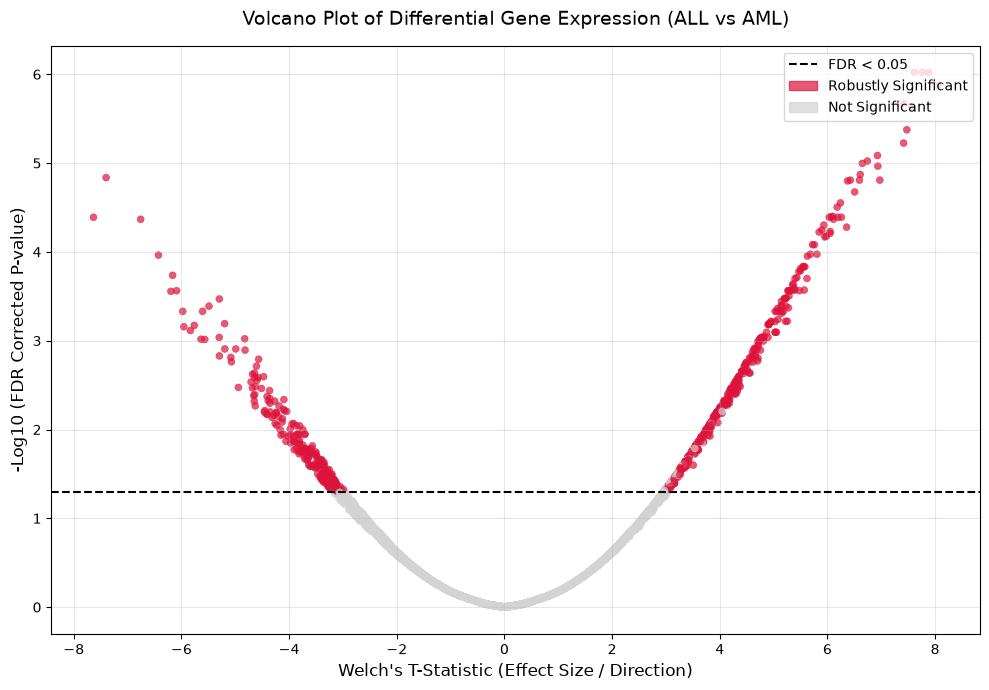

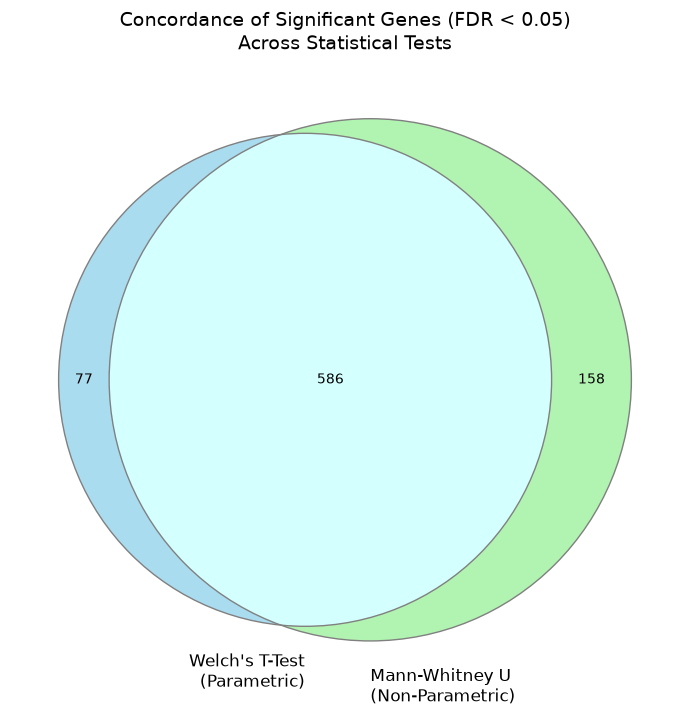

In [21]:
# ==========================================
# 1. VOLCANO PLOT
# ==========================================
# We use the t_stats and pvals_corrected_t arrays generated in Phase 2
volcano_df = pd.DataFrame({
    'Gene_Probe': feature_cols,
    'T_Statistic': t_stats,
    'FDR_P_Value': pvals_corrected_t,
})

# Calculate -log10 of the FDR corrected p-value
# We add a tiny epsilon (1e-300) to prevent log(0) errors for extremely small p-values
volcano_df['neg_log10_FDR'] = -np.log10(volcano_df['FDR_P_Value'] + 1e-300)

# Flag genes that are in our robust baseline (significant in BOTH tests)
volcano_df['Robust_Significant'] = volcano_df['Gene_Probe'].apply(lambda x: x in robust_baseline_genes)

plt.figure(figsize=(10, 7))

# Scatter plot: Gray for not robustly significant, Crimson for robustly significant
sns.scatterplot(
    data=volcano_df,
    x='T_Statistic',
    y='neg_log10_FDR',
    hue='Robust_Significant',
    palette={False: 'lightgray', True: 'crimson'},
    alpha=0.7,
    edgecolor=None,
    s=25
)

# Add a horizontal line for the FDR threshold of 0.05
fdr_threshold_val = -np.log10(0.05)
plt.axhline(fdr_threshold_val, color='black', linestyle='--', linewidth=1.5)

plt.title('Volcano Plot of Differential Gene Expression (ALL vs AML)', fontsize=14, pad=15)
plt.xlabel("Welch's T-Statistic (Effect Size / Direction)", fontsize=12)
plt.ylabel('-Log10 (FDR Corrected P-value)', fontsize=12)

# Customizing the legend for clarity
handles, labels = plt.gca().get_legend_handles_labels()
# The exact handle indices depend on seaborn versions, but usually we just build custom patches
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
red_patch = mpatches.Patch(color='crimson', label='Robustly Significant', alpha=0.7)
gray_patch = mpatches.Patch(color='lightgray', label='Not Significant', alpha=0.7)
thresh_line = mlines.Line2D([], [], color='black', linestyle='--', label='FDR < 0.05')

plt.legend(handles=[thresh_line, red_patch, gray_patch], loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# 2. CONCORDANCE VENN DIAGRAM
# ==========================================
plt.figure(figsize=(7, 7))

# Create the Venn diagram using the Python sets created in Phase 2
venn = venn2(
    subsets=(
        len(set_t - set_mw),              # Genes significant ONLY in T-Test
        len(set_mw - set_t),              # Genes significant ONLY in Mann-Whitney
        len(set_t.intersection(set_mw))   # Genes significant in BOTH (Robust Baseline)
    ),
    set_labels=(
        "Welch's T-Test\n(Parametric)", 
        "Mann-Whitney U\n(Non-Parametric)"
    ),
    set_colors=('skyblue', 'lightgreen'),
    alpha=0.7
)

# Optional: Add outlines to the circles for a cleaner look
try:
    from matplotlib_venn import venn2_circles
    venn2_circles(subsets=(len(set_t - set_mw), len(set_mw - set_t), len(robust_baseline_genes)), 
                  linestyle='solid', linewidth=1.0, color='gray')
except ImportError:
    pass

plt.title('Concordance of Significant Genes (FDR < 0.05)\nAcross Statistical Tests', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### **Phase 3: Classification and Variable Selection**

To handle high-dimensional collinear features ($p \gg n$) and extract a predictive biomarker subset, use L1 regularization.

* **Binary Lasso Regression:** Use `sklearn.linear_model.LogisticRegression` with `penalty='l1'` and `solver='liblinear'` or `'saga'`. This induces sparsity, shrinking the coefficients of irrelevant genes to zero.
* **Alternative (Linear SVM):** Use `sklearn.svm.LinearSVC` with `penalty='l1'` and `dual=False`.
* **Hyperparameter Tuning:** Use `sklearn.model_selection.GridSearchCV` with Stratified K-Fold cross-validation to find the optimal regularization parameter (`C`) that minimizes classification error while maintaining sparsity.

In [22]:
# ==========================================
# 1. SETUP STRATIFIED CROSS-VALIDATION & GRID SEARCH
# ==========================================
# We use 5 splits because our training set is quite small.
# shuffle=True and a random_state ensures reproducibility.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

# Define the hyperparameter grid for C (Inverse of regularization strength).
# Smaller C = Stronger regularization = More sparsity (fewer genes selected).
# param_grid = {'C': np.logspace(-3, -1, 20)}
param_grid = {'C': np.linspace(0.1, 0.8, 20)}

# Initialize the Logistic Regression model with L1 penalty (Lasso).
# 'liblinear' is highly optimized for small datasets and L1 penalties.
lasso_model = LogisticRegression(solver='saga', l1_ratio=1.0, max_iter=10000, random_state=43)

# Setup GridSearchCV to optimize for F1-score (due to class imbalance) instead of mere accuracy
grid_search = GridSearchCV(
    estimator=lasso_model, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='f1', 
    n_jobs=-1
)

# ==========================================
# 2. FIT THE MODEL AND EXTRACT BEST PARAMETERS
# ==========================================
print("Training L1-Regularized Logistic Regression with Stratified CV...")
grid_search.fit(X_train, y_train)

# Extract the best model from the grid search
best_lasso = grid_search.best_estimator_

print(f"\nOptimal Hyperparameter (C): {grid_search.best_params_['C']:.4f}")
print(f"Best Cross-Validated F1-Score: {grid_search.best_score_:.4f}")

# ==========================================
# 3. EXTRACT SPARSITY AND SELECTED BIOMARKERS
# ==========================================
# The coefficients are stored in best_lasso.coef_. Since it's binary, it's a 1D array inside a 2D array.
lasso_coefficients = best_lasso.coef_[0]

# Identify the genes that have non-zero coefficients (these are the selected biomarkers)
selected_indices = np.where(lasso_coefficients != 0)[0]
selected_genes_lasso = [feature_cols[i] for i in selected_indices]
selected_coefs = lasso_coefficients[selected_indices]

# Sort the selected genes by their absolute coefficient value (importance)
importance_df = pd.DataFrame({
    'Gene_Probe': selected_genes_lasso,
    'Coefficient': selected_coefs,
    'Absolute_Weight': np.abs(selected_coefs)
}).sort_values(by='Absolute_Weight', ascending=False)

# ==========================================
# 4. EVALUATE ON THE HOLD-OUT TEST SET (Preview of Phase 5)
# ==========================================
y_pred = best_lasso.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# ==========================================
# 5. OUTPUT DETAILED CONCLUSIONS
# ==========================================
print("\n--- Classification and Variable Selection ---")
print(f"Total features input: {X_train.shape[1]}")
print(f"Features selected by Lasso (Non-zero coefficients): {len(selected_genes_lasso)}")
print(f"Sparsity Achieved: {(1 - len(selected_genes_lasso)/X_train.shape[1])*100:.2f}% of genes eliminated.")

print("\nTop 5 Most Predictive Biomarkers (by coefficient weight):")
print(importance_df.head())

print("\n--- Initial Test Set Evaluation ---")
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"F1-Score: {test_f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["ALL (0)", "AML (1)"]))

# Save the set of Lasso genes for Phase 4 and 5
set_lasso = set(selected_genes_lasso)

Training L1-Regularized Logistic Regression with Stratified CV...



Optimal Hyperparameter (C): 0.7632
Best Cross-Validated F1-Score: 0.9492

--- Classification and Variable Selection ---
Total features input: 7129
Features selected by Lasso (Non-zero coefficients): 92
Sparsity Achieved: 98.71% of genes eliminated.

Top 5 Most Predictive Biomarkers (by coefficient weight):
   Gene_Probe  Coefficient  Absolute_Weight
62  X95735_at     0.242022         0.242022
63  Y07604_at     0.207763         0.207763
15  M19507_at     0.186204         0.186204
47  U82759_at     0.178237         0.178237
29  M84526_at     0.165753         0.165753

--- Initial Test Set Evaluation ---
Accuracy: 100.00%
F1-Score: 1.0000
Confusion Matrix:
[[10  0]
 [ 0  5]]

Classification Report:
              precision    recall  f1-score   support

     ALL (0)       1.00      1.00      1.00        10
     AML (1)       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.0

In [23]:
# # ==========================================
# # 1. SETUP STRATIFIED CROSS-VALIDATION & GRID SEARCH
# # ==========================================
# # We use 5 splits because our training set is quite small.
# # shuffle=True and a random_state ensures reproducibility.
# phase3_repeat_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

# # Define the hyperparameter grid for C (Inverse of regularization strength).
# # Smaller C = Stronger regularization = More sparsity (fewer genes selected).
# phase3_repeat_param_grid = {'C': np.logspace(-3, -1, 20)}

# # Initialize the Logistic Regression model with L1 penalty (Lasso).
# # 'liblinear' is highly optimized for small datasets and L1 penalties.
# phase3_repeat_lasso_model = LogisticRegression(solver='saga', l1_ratio=1.0, max_iter=10000, random_state=43)

# # Setup GridSearchCV to optimize for F1-score (due to class imbalance) instead of mere accuracy
# phase3_repeat_grid_search = GridSearchCV(
#     estimator=phase3_repeat_lasso_model, 
#     param_grid=phase3_repeat_param_grid, 
#     cv=phase3_repeat_skf,
#     scoring='f1', 
#     n_jobs=-1
# )

# # ==========================================
# # 2. FIT THE MODEL AND EXTRACT BEST PARAMETERS
# # ==========================================
# print("Training L1-Regularized Logistic Regression with Stratified CV...")
# phase3_repeat_grid_search.fit(X, y)

# # Extract the best model from the grid search
# phase3_repeat_best_lasso = phase3_repeat_grid_search.best_estimator_

# print(f"\nOptimal Hyperparameter (C): {phase3_repeat_grid_search.best_params_['C']:.4f}")
# print(f"Best Cross-Validated F1-Score: {phase3_repeat_grid_search.best_score_:.4f}")

# # ==========================================
# # 3. EXTRACT SPARSITY AND SELECTED BIOMARKERS
# # ==========================================
# # The coefficients are stored in phase3_repeat_best_lasso.coef_. Since it's binary, it's a 1D array inside a 2D array.
# phase3_repeat_lasso_coefficients = phase3_repeat_best_lasso.coef_[0]

# # Identify the genes that have non-zero coefficients (these are the selected biomarkers)
# phase3_repeat_selected_indices = np.where(phase3_repeat_lasso_coefficients != 0)[0]
# phase3_repeat_selected_genes = [feature_cols[i] for i in phase3_repeat_selected_indices]
# phase3_repeat_selected_coefs = phase3_repeat_lasso_coefficients[phase3_repeat_selected_indices]

# # Sort the selected genes by their absolute coefficient value (importance)
# phase3_repeat_importance_df = pd.DataFrame({
#     'Gene_Probe': phase3_repeat_selected_genes,
#     'Coefficient': phase3_repeat_selected_coefs,
#     'Absolute_Weight': np.abs(phase3_repeat_selected_coefs)
# }).sort_values(by='Absolute_Weight', ascending=False)

# # ==========================================
# # 4. EVALUATE ON THE HOLD-OUT TEST SET (Preview of Phase 5)
# # ==========================================
# phase3_repeat_y_pred = phase3_repeat_best_lasso.predict(X)
# phase3_repeat_test_accuracy = accuracy_score(y, phase3_repeat_y_pred)
# phase3_repeat_test_f1 = f1_score(y, phase3_repeat_y_pred)
# phase3_repeat_conf_matrix = confusion_matrix(y, phase3_repeat_y_pred)

# # ==========================================
# # 5. OUTPUT DETAILED CONCLUSIONS
# # ==========================================
# print("\n--- Classification and Variable Selection ---")
# print(f"Total features input: {X.shape[1]}")
# print(f"Features selected by Lasso (Non-zero coefficients): {len(phase3_repeat_selected_genes)}")
# print(f"Sparsity Achieved: {(1 - len(phase3_repeat_selected_genes)/X.shape[1])*100:.2f}% of genes eliminated.")

# print("\nTop 5 Most Predictive Biomarkers (by coefficient weight):")
# print(phase3_repeat_importance_df.head())

# print("\n--- Initial Test Set Evaluation ---")
# print(f"Accuracy: {phase3_repeat_test_accuracy*100:.2f}%")
# print(f"F1-Score: {phase3_repeat_test_f1:.4f}")
# print("Confusion Matrix:")
# print(phase3_repeat_conf_matrix)
# print("\nClassification Report:")
# print(classification_report(y, phase3_repeat_y_pred, target_names=["ALL (0)", "AML (1)"]))

# # Save the set of Lasso genes for Phase 4 and 5
# phase3_repeat_set_lasso = set(phase3_repeat_selected_genes)

### **Phase 4: Variable Selection Stability (Core Requirement)**

You must explicitly document how multi-collinearity affects sparsity and compute true feature inclusion probabilities.

* **Bootstrapping:** Use `sklearn.utils.resample` to create $B$ bootstrap samples (e.g., $B=100$) of your training data.
* **Model Iteration:** Fit your optimally tuned L1 Logistic Regression (or SVM) on each bootstrap sample.
* **Stability Mapping:** For each run, record which genes have non-zero coefficients.
* **Inclusion Probabilities:** Calculate the proportion of times each gene was selected across the $B$ runs. A gene selected 95 out of 100 times has an inclusion probability of 0.95 (highly stable). Document how collinearity might cause some genes' probabilities to fluctuate.

In [24]:
# ==========================================
# 1. SETUP BOOTSTRAPPING
# ==========================================
B = 100 # Number of bootstrap iterations
optimal_C = grid_search.best_params_['C']

# Initialize a fast Lasso model using your optimal C and a looser tolerance
# to prevent ConvergenceWarnings and speed up the loop
boot_lasso = LogisticRegression(
    solver='saga', 
    l1_ratio=1.0, 
    C=optimal_C, 
    max_iter=10000, 
    # tol=1e-3,          # <--- Stops early once adjustments are tiny
    random_state=43
)

# This list will store the names of every gene selected across all 100 runs
all_selected_genes = []

print(f"Running Stability Analysis ({B} Bootstrap Samples)...")

# ==========================================
# 2. RUN BOOTSTRAP ITERATIONS
# ==========================================
for i in range(B):
    # Create a bootstrap sample (random sampling with replacement)
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    
    # Fit the model on the bootstrap sample
    boot_lasso.fit(X_boot, y_boot)
    
    # Extract the indices of genes with non-zero coefficients
    nonzero_indices = np.where(boot_lasso.coef_[0] != 0)[0]
    
    # Map indices back to actual gene names and add to our master list
    selected_genes = [feature_cols[idx] for idx in nonzero_indices]
    all_selected_genes.extend(selected_genes)

# ==========================================
# 3. CALCULATE INCLUSION PROBABILITIES
# ==========================================
# Count how many times each gene was selected
gene_counts = Counter(all_selected_genes)

# Calculate inclusion probability (Count / B)
stability_df = pd.DataFrame.from_dict(gene_counts, orient='index', columns=['Selection_Count'])
stability_df['Inclusion_Probability'] = stability_df['Selection_Count'] / B
stability_df.index.name = 'Gene_Probe'
stability_df = stability_df.reset_index()

# Sort by most stable (Probability closer to 1.0)
stability_df = stability_df.sort_values(by='Inclusion_Probability', ascending=False)

# Define our FINAL robust biomarker panel (e.g., genes selected in >80% of bootstraps)
highly_stable_genes = stability_df[stability_df['Inclusion_Probability'] >= 0.80]

print("\n--- Variable Selection Stability ---")
print(f"Total unique genes selected at least once across {B} runs: {len(stability_df)}")
print(f"Highly stable biomarkers (Inclusion Probability >= 80%): {len(highly_stable_genes)}")

print("\nTop 10 Most Stable Biomarkers:")
print(stability_df.head(10).to_string(index=False))

# ==========================================
# 4. PHASE 5: THE FINAL CONTRAST (Control of False Discoveries)
# ==========================================
# Compare our highly stable Machine Learning biomarkers to the Phase 2 Statistical Baseline
final_ml_set = set(highly_stable_genes['Gene_Probe'])

# robust_baseline_genes is the intersection of T-Test and Mann-Whitney from Phase 2
overlap = final_ml_set.intersection(robust_baseline_genes)

print("\n--- Synthesis & Final Contrast ---")
print(f"Number of ML Biomarkers: {len(final_ml_set)}")
print(f"Number of ML Biomarkers that were ALSO statistically significant: {len(overlap)}")
if len(final_ml_set) > 0:
    print(f"Concordance Rate: {(len(overlap)/len(final_ml_set))*100:.2f}%")

Running Stability Analysis (100 Bootstrap Samples)...

--- Variable Selection Stability ---
Total unique genes selected at least once across 100 runs: 829
Highly stable biomarkers (Inclusion Probability >= 80%): 12

Top 10 Most Stable Biomarkers:
 Gene_Probe  Selection_Count  Inclusion_Probability
  M84526_at               99                   0.99
  X95735_at               99                   0.99
  M22960_at               94                   0.94
  M23197_at               92                   0.92
L09209_s_at               89                   0.89
  M63138_at               88                   0.88
  Y07604_at               86                   0.86
  M19507_at               85                   0.85
  X17042_at               85                   0.85
  U82759_at               84                   0.84

--- Synthesis & Final Contrast ---
Number of ML Biomarkers: 12
Number of ML Biomarkers that were ALSO statistically significant: 12
Concordance Rate: 100.00%


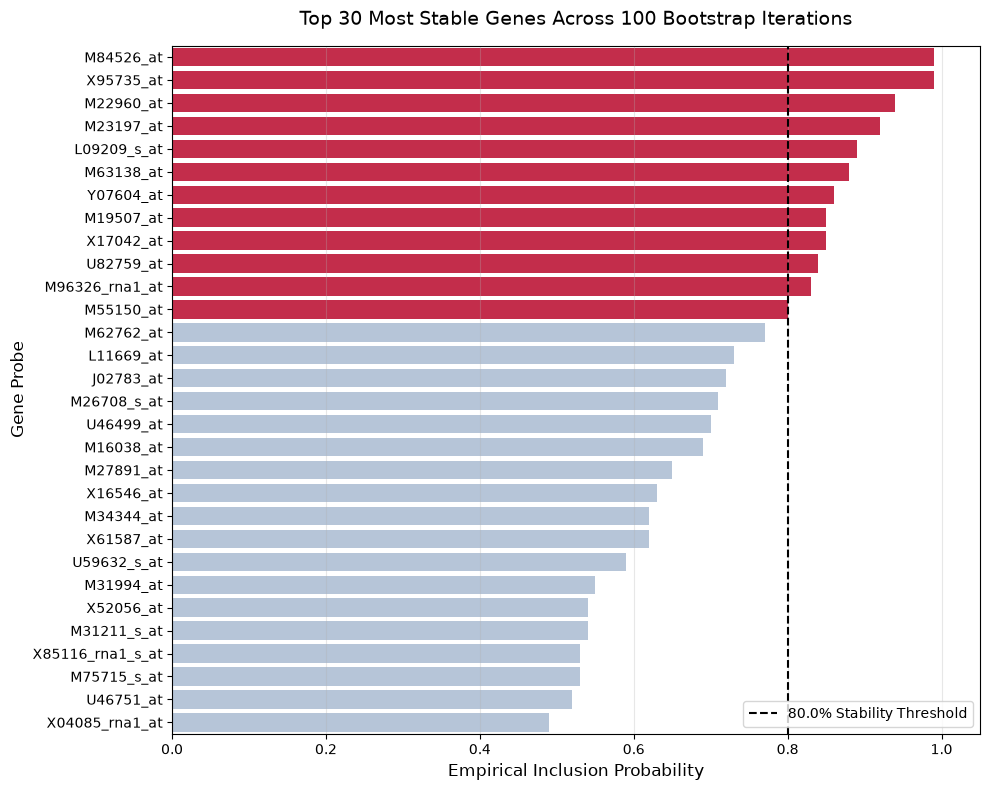

Calculating Lasso regularization path...


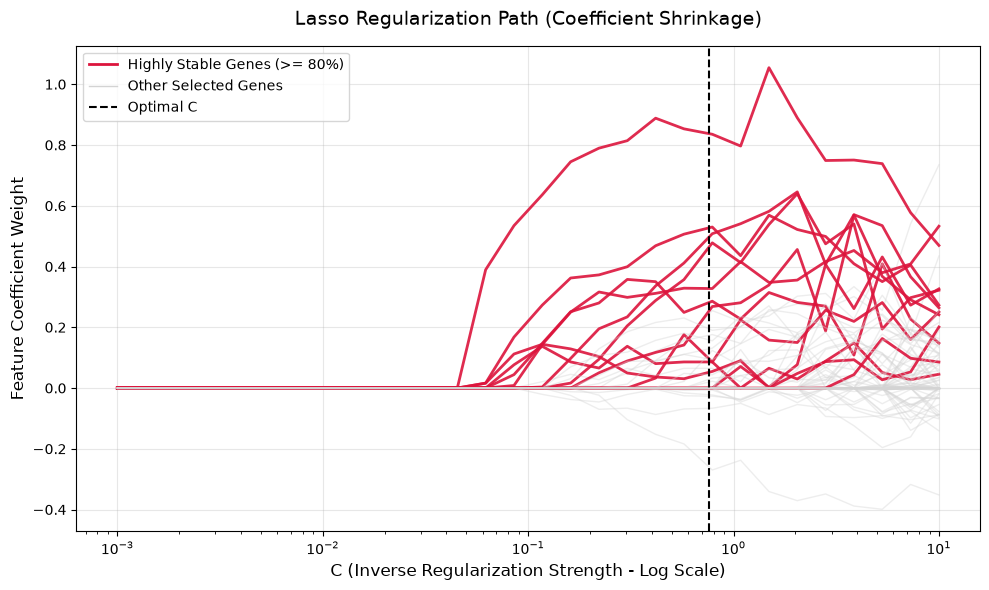

In [25]:
# ==========================================
# 1. INCLUSION PROBABILITY BAR CHART
# ==========================================
# Select the top 30 most stable genes for visualization to keep the chart readable
top_n = 30
plot_df = stability_df.head(top_n).copy()

# Create a color palette: highlight genes that meet the 80% threshold
threshold = 0.80
colors = ['crimson' if prob >= threshold else 'lightsteelblue' for prob in plot_df['Inclusion_Probability']]

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=plot_df, 
    x='Inclusion_Probability', 
    y='Gene_Probe', 
    palette=colors,
    hue='Gene_Probe', 
    legend=False
)

# Add a vertical line for the stability threshold
plt.axvline(threshold, color='black', linestyle='--', linewidth=1.5, label=f'{threshold*100}% Stability Threshold')

plt.title(f'Top {top_n} Most Stable Genes Across 100 Bootstrap Iterations', fontsize=14, pad=15)
plt.xlabel('Empirical Inclusion Probability', fontsize=12)
plt.ylabel('Gene Probe', fontsize=12)
plt.xlim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# 2. LASSO REGULARIZATION PATH
# ==========================================
# To show how L1 regularization induces sparsity and handles collinearity, 
# we calculate the coefficients across a range of C values (inverse regularization).
C_values = np.logspace(-3, 1, 30)
coef_path = []

# Fit a fast Lasso model for each C value
print("Calculating Lasso regularization path...")
for c in C_values:
    clf = LogisticRegression(
        penalty='l1', 
        solver='liblinear', 
        C=c, 
        random_state=43, 
        max_iter=1000
    )
    clf.fit(X_train, y_train)
    coef_path.append(clf.coef_[0])

coef_path = np.array(coef_path)

plt.figure(figsize=(10, 6))

# Plotting 7,129 lines is computationally heavy and visually unreadable.
# We will only plot the paths for the genes that were selected in your optimally tuned Phase 3 model.
for idx in selected_indices:
    # Highlight the 12 highly stable genes from Phase 4 in crimson, others in gray
    gene_name = feature_cols[idx]
    is_stable = gene_name in final_ml_set
    
    color = 'crimson' if is_stable else 'lightgray'
    alpha = 0.9 if is_stable else 0.4
    linewidth = 2 if is_stable else 1
    
    plt.plot(C_values, coef_path[:, idx], color=color, alpha=alpha, linewidth=linewidth)

# Logarithmic scale for the x-axis is standard for regularization paths
plt.xscale('log')

# Add a vertical line marking the optimal C value found via GridSearchCV in Phase 3
plt.axvline(optimal_C, color='black', linestyle='--', label=f'Optimal C ({optimal_C:.4f})')

# Custom legend
import matplotlib.lines as mlines
stable_line = mlines.Line2D([], [], color='crimson', linewidth=2, label='Highly Stable Genes (>= 80%)')
unstable_line = mlines.Line2D([], [], color='lightgray', linewidth=1, label='Other Selected Genes')
opt_c_line = mlines.Line2D([], [], color='black', linestyle='--', label='Optimal C')

plt.title('Lasso Regularization Path (Coefficient Shrinkage)', fontsize=14, pad=15)
plt.xlabel('C (Inverse Regularization Strength - Log Scale)', fontsize=12)
plt.ylabel('Feature Coefficient Weight', fontsize=12)
plt.legend(handles=[stable_line, unstable_line, opt_c_line], loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Phase 5: Synthesis and Final Evaluation**

* **The Contrast:** Use Python sets to compare your statistically significant genes (from Phase 2) against the predictive biomarkers selected by your stable ML model (Phase 4).
* **Evaluation Metrics:** Evaluate the final model on a hidden test set based on three criteria:
    1. **Binary classification error** (Accuracy, F1-Score).
    2. **Sparsity** (the exact number of final selected genes).
    3. **Reproducibility/Stability score** (e.g., the average inclusion probability of your final biomarker subset).
* **Submission Formatting:** Your Python script must be error-free and shared via a notebook on Google Colab. Provide the link at the end of your PDF report. Ensure the notebook outputs a detailed explanation of your conclusions, not just raw numbers.

--- Phase 5: Final Clinical Model Evaluation ---
Number of Biomarkers Used: 12
Final Test Accuracy: 100.00%
Final Test F1-Score: 1.0000

Classification Report on 12-Gene Panel:
              precision    recall  f1-score   support

     ALL (0)       1.00      1.00      1.00        10
     AML (1)       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



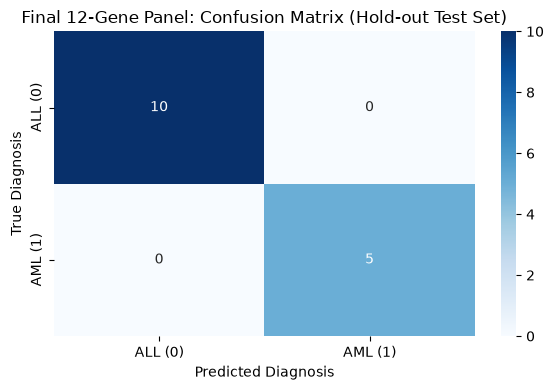


--- Final Biological Synthesis ---
Machine Learning Biomarkers: 12
Statistically Significant in Phase 2 Baseline: 12
Concordance Rate (False Discovery Control): 100.00%


In [26]:
# ==========================================
# 1. ISOLATE THE FINAL BIOMARKER PANEL (CORRECTED)
# ==========================================
# Extract the list of our 12 highly stable genes from Phase 4
final_genes = highly_stable_genes['Gene_Probe'].tolist()

# Find the exact numerical column indices for these 12 genes
# (Converting feature_cols to a list in case it's a pandas Index)
feature_list = list(feature_cols)
final_indices = [feature_list.index(gene) for gene in final_genes]

# Subset the NumPy arrays using these numerical indices
# The ":" means "take all patients (rows)", and final_indices takes the specific columns
X_train_final = X_train[:, final_indices]
X_test_final = X_test[:, final_indices]

# ==========================================
# 2. TRAIN THE FINAL CLINICAL CLASSIFIER
# ==========================================
# Since feature selection is fully complete, we no longer need the harsh L1 Lasso penalty.
# We use a standard Logistic Regression (with a standard L2 penalty) to get the final weights.
final_model = LogisticRegression(C=1.0, solver='lbfgs', random_state=43)
final_model.fit(X_train_final, y_train)

# ==========================================
# 3. EVALUATE ON THE HOLD-OUT TEST SET
# ==========================================
y_pred_final = final_model.predict(X_test_final)

final_acc = accuracy_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_cm = confusion_matrix(y_test, y_pred_final)

print("--- Phase 5: Final Clinical Model Evaluation ---")
print(f"Number of Biomarkers Used: {len(final_genes)}")
print(f"Final Test Accuracy: {final_acc*100:.2f}%")
print(f"Final Test F1-Score: {final_f1:.4f}\n")

print("Classification Report on 12-Gene Panel:")
print(classification_report(y_test, y_pred_final, target_names=["ALL (0)", "AML (1)"]))

# ==========================================
# 4. VISUALIZE CONFUSION MATRIX FOR THE REPORT
# ==========================================
plt.figure(figsize=(6, 4))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["ALL (0)", "AML (1)"], 
            yticklabels=["ALL (0)", "AML (1)"])
plt.title('Final 12-Gene Panel: Confusion Matrix (Hold-out Test Set)')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('True Diagnosis')
plt.tight_layout()
plt.show()

# ==========================================
# 5. FINAL BIOLOGICAL SYNTHESIS (False Discovery Control)
# ==========================================
# robust_baseline_genes is the intersection of T-Test and Mann-Whitney from Phase 2
overlap = set(final_genes).intersection(robust_baseline_genes)

print("\n--- Final Biological Synthesis ---")
print(f"Machine Learning Biomarkers: {len(final_genes)}")
print(f"Statistically Significant in Phase 2 Baseline: {len(overlap)}")
if len(final_genes) > 0:
    print(f"Concordance Rate (False Discovery Control): {(len(overlap)/len(final_genes))*100:.2f}%")

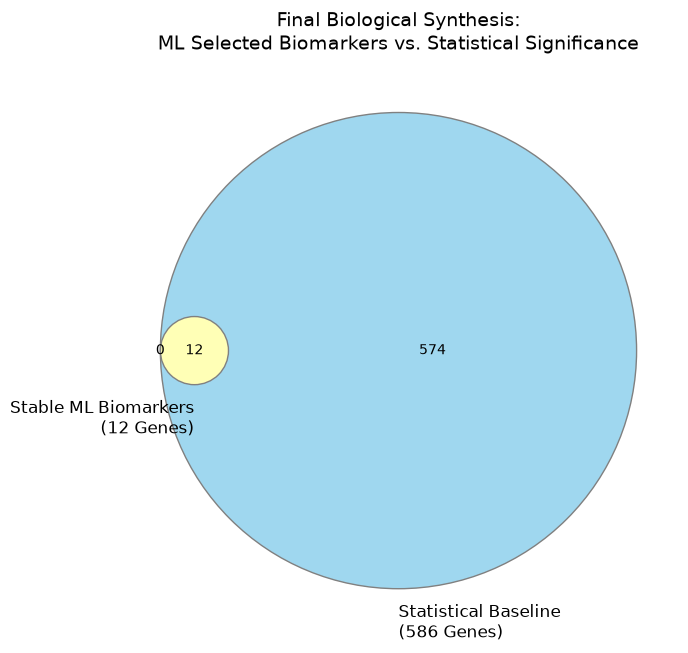

In [27]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# ==========================================
# FINAL BIOLOGICAL SYNTHESIS VENN DIAGRAM
# ==========================================
plt.figure(figsize=(7, 7))

# Create the Venn diagram using the sets from Phase 2 and Phase 4
venn = venn2(
    subsets=(
        len(final_ml_set - robust_baseline_genes),            # ML genes NOT statistically significant
        len(robust_baseline_genes - final_ml_set),            # Statistically significant genes NOT picked by ML
        len(final_ml_set.intersection(robust_baseline_genes)) # Genes in BOTH (Concordance)
    ),
    set_labels=(
        f"Stable ML Biomarkers\n({len(final_ml_set)} Genes)", 
        f"Statistical Baseline\n({len(robust_baseline_genes)} Genes)"
    ),
    set_colors=('gold', 'skyblue'),
    alpha=0.8
)

# Add solid outlines to the circles for a cleaner presentation
try:
    from matplotlib_venn import venn2_circles
    venn2_circles(
        subsets=(
            len(final_ml_set - robust_baseline_genes), 
            len(robust_baseline_genes - final_ml_set), 
            len(final_ml_set.intersection(robust_baseline_genes))
        ), 
        linestyle='solid', 
        linewidth=1.0, 
        color='gray'
    )
except ImportError:
    pass

plt.title('Final Biological Synthesis:\nML Selected Biomarkers vs. Statistical Significance', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [15]:
y_train

Samples
5     0
29    1
68    0
63    1
62    1
38    1
8     0
44    0
10    0
4     0
33    1
51    1
28    1
20    0
31    1
12    0
15    0
47    0
9     0
52    1
43    0
7     0
61    1
27    0
22    0
45    0
46    0
64    1
54    1
71    0
3     0
48    0
23    0
34    1
21    0
1     0
14    0
40    0
57    1
70    0
17    0
2     0
39    0
50    1
66    1
13    0
42    0
60    1
26    0
55    0
18    0
67    0
25    0
53    1
16    0
37    1
30    1
Name: target, dtype: int64

In [29]:
# Convert NumPy arrays to Pandas DataFrame/Series as required by the mrmr package
X_train_df = pd.DataFrame(X_train)
y_train_series = pd.Series(y_train)
X_test_df = pd.DataFrame(X_test)

X_train_df.shape, y_train_series.shape, X_test_df.shape

((57, 7129), (57,), (15, 7129))

In [30]:
# Convert NumPy arrays to Pandas DataFrame/Series as required by the mrmr package
X_train_df = pd.DataFrame(X_train)
y_train_series = pd.Series(np.array(y_train))
X_test_df = pd.DataFrame(X_test)

# Define the number of features to retain after the mRMR phase
# 100 features reduces the 7,129 gene space significantly while preserving relevance
K_MRMR = 100

print(f"Starting mRMR feature selection. Selecting top {K_MRMR} features...")

# Execute mRMR selection
# Note: mrmr_classif calculates mutual information and explicitly penalizes redundancy
selected_features_mrmr = mrmr_classif(X=X_train_df, y=y_train_series, K=K_MRMR)

# Transform the training and testing sets to include only the mRMR-selected genes
X_train_mrmr = X_train_df[selected_features_mrmr]
X_test_mrmr = X_test_df[selected_features_mrmr]

print(f"mRMR complete. Features reduced from {X_train_df.shape[1]} to {X_train_mrmr.shape[1]}.")

#Initialize a linear Support Vector Classifier and wrap it in `RFECV`. A 5-fold stratified cross-validation is used to ensure class balance (ALL vs. AML) across folds during evaluation.

# Initialize the base estimator (Linear SVM)
svc = SVC(kernel='linear', random_state=42)

# Define the cross-validation strategy
# StratifiedKFold maintains the class distribution of 47 ALL and 25 AML samples
cv = StratifiedKFold(n_splits=5)

# Initialize RFECV
# step=1 removes one feature at a time for high granularity
rfecv = RFECV(estimator=svc, 
              step=1, 
              cv=cv, 
              scoring='f1', 
              min_features_to_select=1,
              n_jobs=-1)  # Utilize all CPU cores

print("Starting SVM-RFE wrapper selection...")
rfecv.fit(X_train_mrmr, y_train)

# Identify the optimal number of features and extract their names
optimal_num_features = rfecv.n_features_
optimal_genes = X_train_mrmr.columns[rfecv.support_]

print(f"SVM-RFE complete. Optimal number of features: {optimal_num_features}")
print("Final selected genes:", list(optimal_genes))

# Transform the datasets to include only the final optimal genes
X_train_final = rfecv.transform(X_train_mrmr)
X_test_final = rfecv.transform(X_test_mrmr)


#Fit the final classifier using only the optimally selected gene signature and evaluate its performance on the unseen test set.

# Train the final SVM model using the optimally selected features
final_model = SVC(kernel='linear', random_state=42)
final_model.fit(X_train_final, y_train)

# Generate predictions on the test set
y_pred = final_model.predict(X_test_final)

# Calculate and display evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Final Model Test Accuracy: {accuracy:.4f}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Starting mRMR feature selection. Selecting top 100 features...


100%|██████████| 100/100 [00:21<00:00,  4.67it/s]


mRMR complete. Features reduced from 7129 to 100.
Starting SVM-RFE wrapper selection...
SVM-RFE complete. Optimal number of features: 21
Final selected genes: [4846, 1828, 1833, 2120, 1974, 1778, 2401, 3846, 4950, 1925, 3257, 5279, 6183, 6538, 2353, 6224, 489, 4696, 4652, 6361, 2738]
Final Model Test Accuracy: 1.0000

Confusion Matrix:
[[10  0]
 [ 0  5]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



Starting Stability Analysis: mRMR + SVM-RFE across 100 Bootstrap Samples...
This may take a while depending on your CPU...
Processing Bootstrap Iteration 0/100...
Processing Bootstrap Iteration 10/100...
Processing Bootstrap Iteration 20/100...
Processing Bootstrap Iteration 30/100...
Processing Bootstrap Iteration 40/100...
Processing Bootstrap Iteration 50/100...
Processing Bootstrap Iteration 60/100...
Processing Bootstrap Iteration 70/100...
Processing Bootstrap Iteration 80/100...
Processing Bootstrap Iteration 90/100...

--- SVM Pipeline: Variable Selection Stability ---
Total unique genes selected at least once across 100 runs: 412
Highly stable biomarkers (Inclusion Probability >= 80%): 0

Top 10 Most Stable SVM Biomarkers:
    Gene_Probe  Selection_Count  Inclusion_Probability
     X95735_at               73                   0.73
     Y07604_at               63                   0.63
     M19507_at               57                   0.57
     U82759_at               57       

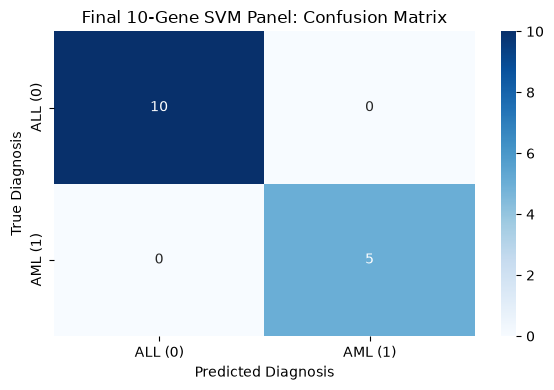

In [33]:
# ==========================================
# 1. SETUP BOOTSTRAPPING FOR mRMR + SVM-RFE
# ==========================================
B = 100  # Number of bootstrap iterations
K_MRMR = 100  # Number of genes to filter in the mRMR step

all_selected_svm_genes = []

# Define a targeted grid for SVM C-parameter tuning
# Smaller C = Stronger regularization (wider margin)
svm_param_grid = {'C': [0.01, 0.1, 1.0, 10.0]}

print(f"Starting Stability Analysis: mRMR + SVM-RFE across {B} Bootstrap Samples...")
print("This may take a while depending on your CPU...")

# ==========================================
# 2. RUN BOOTSTRAP ITERATIONS
# ==========================================
for i in range(B):
    if i % 10 == 0:
        print(f"Processing Bootstrap Iteration {i}/{B}...")
        
    # Create a bootstrap sample
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    
    # Safely convert to Pandas and strip indices to prevent IndexingErrors with mRMR
    # Assuming `feature_cols` contains your 7,129 gene names (fallback to default indices if not)
    X_boot_df = pd.DataFrame(X_boot, columns=feature_cols if 'feature_cols' in globals() else None)
    y_boot_series = pd.Series(np.array(y_boot))
    
    # --- Step A: mRMR Filter ---
    # show_progress=False prevents 100 progress bars from flooding your terminal
    mrmr_features = mrmr_classif(X=X_boot_df, y=y_boot_series, K=K_MRMR, show_progress=False)
    X_boot_mrmr = X_boot_df[mrmr_features]
    
    # --- Step B: Tune the SVM Base Estimator ---
    # We use F1-score to account for the ALL/AML class imbalance
    skf_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=i)
    svm_tuner = GridSearchCV(
        SVC(kernel='linear', class_weight='balanced', random_state=i), 
        param_grid=svm_param_grid, 
        cv=skf_tune, 
        scoring='f1',
        n_jobs=-1
    )
    svm_tuner.fit(X_boot_mrmr, y_boot)
    best_svc = svm_tuner.best_estimator_
    
    # --- Step C: SVM-RFE Wrapper ---
    skf_rfe = StratifiedKFold(n_splits=3, shuffle=True, random_state=i)
    rfecv = RFECV(
        estimator=best_svc, 
        step=1, 
        cv=skf_rfe, 
        scoring='f1',  # Changed from 'accuracy' to 'f1'
        min_features_to_select=1,
        n_jobs=-1
    )
    rfecv.fit(X_boot_mrmr, y_boot)
    
    # Extract and store the optimal genes selected in this bootstrap run
    selected_in_boot = X_boot_mrmr.columns[rfecv.support_].tolist()
    all_selected_svm_genes.extend(selected_in_boot)

# ==========================================
# 3. CALCULATE INCLUSION PROBABILITIES
# ==========================================
# Count how many times each gene was selected across all 100 runs
svm_gene_counts = Counter(all_selected_svm_genes)

svm_stability_df = pd.DataFrame.from_dict(svm_gene_counts, orient='index', columns=['Selection_Count'])
svm_stability_df['Inclusion_Probability'] = svm_stability_df['Selection_Count'] / B
svm_stability_df.index.name = 'Gene_Probe'
svm_stability_df = svm_stability_df.reset_index()

# Sort by most stable
svm_stability_df = svm_stability_df.sort_values(by='Inclusion_Probability', ascending=False)

# Define our FINAL robust biomarker panel (e.g., selected in >80% of bootstraps)
stable_svm_genes = svm_stability_df[svm_stability_df['Inclusion_Probability'] >= 0.80]

print("\n--- SVM Pipeline: Variable Selection Stability ---")
print(f"Total unique genes selected at least once across {B} runs: {len(svm_stability_df)}")
print(f"Highly stable biomarkers (Inclusion Probability >= 80%): {len(stable_svm_genes)}")

print("\nTop 10 Most Stable SVM Biomarkers:")
print(svm_stability_df.head(10).to_string(index=False))

# ==========================================
# 4. TRAIN AND EVALUATE FINAL CLINICAL MODEL
# ==========================================
# Extract the highly stable gene names
final_svm_features = stable_svm_genes['Gene_Probe'].tolist()

# Handle edge case: if no genes reached the 80% threshold, fallback to the top 10 most stable
if len(final_svm_features) == 0:
    print("\nWarning: No genes reached 80% stability. Defaulting to top 10 most stable genes.")
    final_svm_features = svm_stability_df.head(10)['Gene_Probe'].tolist()

# Safely extract these columns from the original full data
# (Assumes X_train and X_test can be wrapped in pandas DataFrames aligned with feature_cols)
X_train_df = pd.DataFrame(X_train, columns=feature_cols if 'feature_cols' in globals() else None)
X_test_df = pd.DataFrame(X_test, columns=feature_cols if 'feature_cols' in globals() else None)

X_train_final_svm = X_train_df[final_svm_features]
X_test_final_svm = X_test_df[final_svm_features]

# Train the final tuned SVM model
final_svm_model = SVC(kernel='linear', class_weight='balanced', C=1.0, random_state=42)
final_svm_model.fit(X_train_final_svm, y_train)

# Evaluate on Hold-out Test Set
y_pred_svm = final_svm_model.predict(X_test_final_svm)

final_svm_acc = accuracy_score(y_test, y_pred_svm)
final_svm_f1 = f1_score(y_test, y_pred_svm)
final_svm_cm = confusion_matrix(y_test, y_pred_svm)

print("\n--- Phase 5: Final SVM Model Evaluation ---")
print(f"Number of Biomarkers Used: {len(final_svm_features)}")
print(f"Final Test Accuracy: {final_svm_acc*100:.2f}%")
print(f"Final Test F1-Score: {final_svm_f1:.4f}\n")

print("Classification Report on Stable SVM Panel:")
print(classification_report(y_test, y_pred_svm, target_names=["ALL (0)", "AML (1)"]))

# ==========================================
# 5. VISUALIZE CONFUSION MATRIX
# ==========================================
plt.figure(figsize=(6, 4))
sns.heatmap(final_svm_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["ALL (0)", "AML (1)"], 
            yticklabels=["ALL (0)", "AML (1)"])
plt.title(f'Final {len(final_svm_features)}-Gene SVM Panel: Confusion Matrix')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('True Diagnosis')
plt.tight_layout()
plt.show()

In [34]:
# --- Phase 1: Hyperparameter Tuning ---
print("Phase 1: Tuning Elastic Net Hyperparameters...")

# For classification, we use LogisticRegression with the 'elasticnet' penalty and 'saga' solver
param_grid = {
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    'C': np.logspace(-2, 2, 10)  # C is the inverse of regularization strength
}

# Initialize model and grid search
en_base_model = LogisticRegression(
    penalty='elasticnet', 
    solver='saga', 
    max_iter=5000, 
    random_state=42
)
grid_search = GridSearchCV(
    en_base_model, 
    param_grid, 
    cv=5, 
    scoring='neg_log_loss', 
    n_jobs=-1
)

# Fit the grid search to find optimal balance
grid_search.fit(X_train, y_train)

best_l1_ratio = grid_search.best_params_['l1_ratio']
best_C = grid_search.best_params_['C']

print(f"Optimal l1_ratio: {best_l1_ratio}")
print(f"Optimal C: {best_C}")


# --- Phase 2: Variable Selection Stability (Bootstrapping) ---
print("\nPhase 2: Running Bootstrapping Loop...")

n_iterations = 100 # Adjust to 500 if matching a longer previous run
n_features = X_train.shape[1]
selection_counts = np.zeros(n_features)

for i in range(n_iterations):
    # Create a bootstrap sample (sampling with replacement)
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    
    # Fit Elastic Net on the bootstrap sample
    boot_model = LogisticRegression(
        penalty='elasticnet', 
        solver='saga', 
        C=best_C, 
        l1_ratio=best_l1_ratio, 
        max_iter=5000, 
        random_state=42
    )
    boot_model.fit(X_boot, y_boot)
    
    # Extract indices of genes that received a non-zero coefficient
    non_zero_indices = np.where(boot_model.coef_[0] != 0)[0]
    
    # Increment inclusion counts for those genes
    selection_counts[non_zero_indices] += 1

# Calculate final empirical inclusion probabilities
inclusion_probabilities = selection_counts / n_iterations


# --- Phase 3: Thresholding and Metric Extraction ---
print("\nPhase 3: Thresholding and Evaluation...")

threshold = 0.80
stable_genes_mask = inclusion_probabilities >= threshold
num_stable_genes = np.sum(stable_genes_mask)

print(f"Number of stable genes (>= 80% inclusion): {num_stable_genes}")

if num_stable_genes > 0:
    # Handle both Pandas DataFrames and Numpy Arrays for filtering
    if isinstance(X_train, pd.DataFrame):
        X_train_filtered = X_train.iloc[:, stable_genes_mask]
        X_test_filtered = X_test.iloc[:, stable_genes_mask]
    else:
        X_train_filtered = X_train[:, stable_genes_mask]
        X_test_filtered = X_test[:, stable_genes_mask]
    
    # Train an essentially unpenalized classifier on the isolated stable genes 
    # (High C acts as no penalty to evaluate the raw predictive power of the genes)
    eval_classifier = LogisticRegression(penalty='l2', C=1e5, max_iter=5000, random_state=42)
    eval_classifier.fit(X_train_filtered, y_train)
    
    # Predict and evaluate
    y_pred = eval_classifier.predict(X_test_filtered)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1-Score: {f1:.4f}")
else:
    print("No genes reached the stability threshold.")

Phase 1: Tuning Elastic Net Hyperparameters...
Optimal l1_ratio: 0.5
Optimal C: 0.5994842503189409

Phase 2: Running Bootstrapping Loop...

Phase 3: Thresholding and Evaluation...
Number of stable genes (>= 80% inclusion): 24
Test Accuracy: 1.0000
Test F1-Score: 1.0000


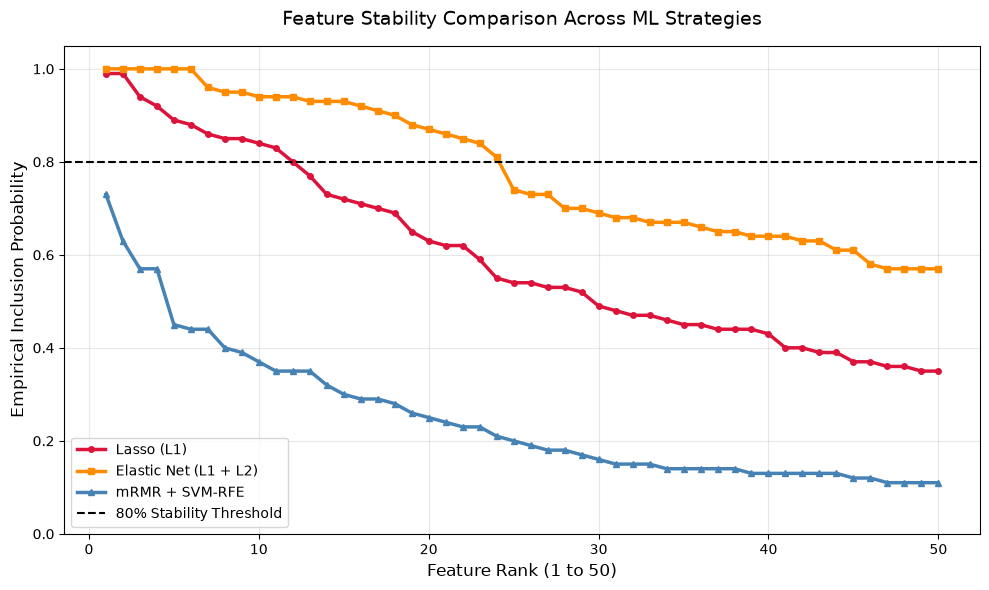

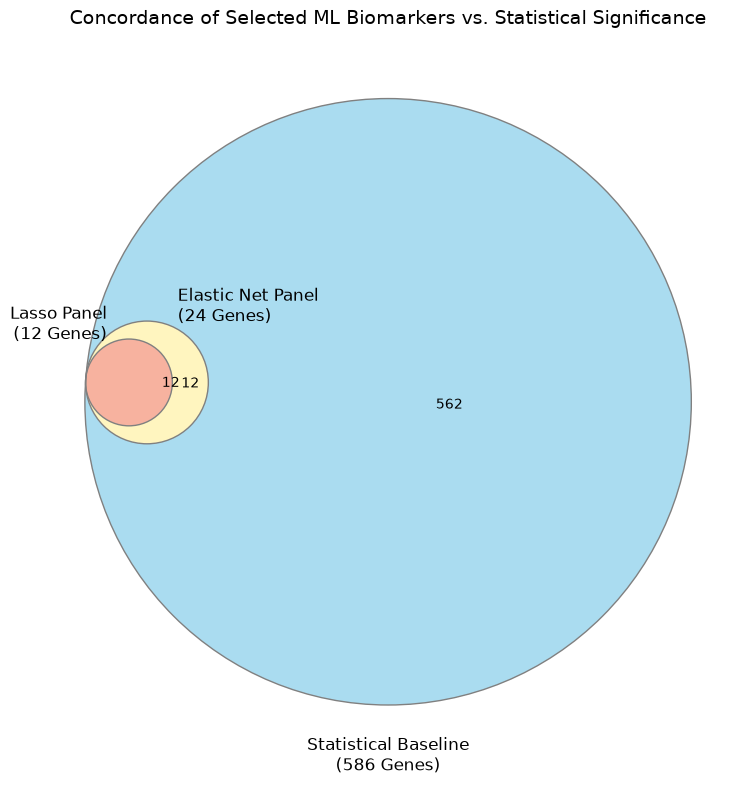


--- Final Methodological Comparison ---


,Method,Test Accuracy,Sparsity (Final Genes),Max Inclusion Probability,Variables >= 80% Stable
0,Lasso (Pure L1),100.00%,12,0.99,12
1,Elastic Net (L1 + L2),100.00%,24,1.00,24
2,mRMR + SVM-RFE,100.00%,10,0.73,0


In [35]:
# ==========================================
# PREPARATION: Extract Elastic Net Data
# ==========================================
# We need to format the Elastic Net array to match the Pandas structures of the other models
en_stability_df = pd.DataFrame({
    'Gene_Probe': feature_cols,
    'Inclusion_Probability': inclusion_probabilities
}).sort_values(by='Inclusion_Probability', ascending=False).reset_index(drop=True)

# Create a Python set for the stable Elastic Net genes (>= 80%)
en_stable_set = set(en_stability_df[en_stability_df['Inclusion_Probability'] >= 0.80]['Gene_Probe'])

# We already have these sets from previous phases:
# - robust_baseline_genes (Phase 2)
# - final_ml_set (Phase 4 Lasso)

# ==========================================
# 1. STABILITY DROP-OFF LINE PLOT
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the top 50 genes for each method to show the steepness of the drop-off
ranks = range(1, 51)
plt.plot(ranks, stability_df['Inclusion_Probability'].head(50), 
         label='Lasso (L1)', color='crimson', linewidth=2.5, marker='o', markersize=4)
plt.plot(ranks, en_stability_df['Inclusion_Probability'].head(50), 
         label='Elastic Net (L1 + L2)', color='darkorange', linewidth=2.5, marker='s', markersize=4)
plt.plot(ranks, svm_stability_df['Inclusion_Probability'].head(50), 
         label='mRMR + SVM-RFE', color='steelblue', linewidth=2.5, marker='^', markersize=4)

# Add threshold line
plt.axhline(0.80, color='black', linestyle='--', linewidth=1.5, label='80% Stability Threshold')

plt.title('Feature Stability Comparison Across ML Strategies', fontsize=14, pad=15)
plt.xlabel('Feature Rank (1 to 50)', fontsize=12)
plt.ylabel('Empirical Inclusion Probability', fontsize=12)
plt.ylim(0, 1.05)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# 2. METHOD CONCORDANCE VENN DIAGRAM
# ==========================================
plt.figure(figsize=(8, 8))

# Create a 3-way Venn Diagram
venn = venn3(
    subsets=[final_ml_set, en_stable_set, robust_baseline_genes],
    set_labels=(
        f"Lasso Panel\n({len(final_ml_set)} Genes)", 
        f"Elastic Net Panel\n({len(en_stable_set)} Genes)", 
        f"Statistical Baseline\n({len(robust_baseline_genes)} Genes)"
    ),
    set_colors=('crimson', 'darkorange', 'skyblue'),
    alpha=0.7
)

# Optional: Add outlines to circles
try:
    from matplotlib_venn import venn3_circles
    venn3_circles(
        subsets=[final_ml_set, en_stable_set, robust_baseline_genes], 
        linestyle='solid', linewidth=1.0, color='gray'
    )
except ImportError:
    pass

plt.title('Concordance of Selected ML Biomarkers vs. Statistical Significance', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


# ==========================================
# 3. SUMMARY COMPARISON TABLE
# ==========================================
# Compile the metrics generated across your notebook phases
summary_data = {
    'Method': ['Lasso (Pure L1)', 'Elastic Net (L1 + L2)', 'mRMR + SVM-RFE'],
    'Test Accuracy': [f"{final_acc*100:.2f}%", f"{acc*100:.2f}%", f"{final_svm_acc*100:.2f}%"],
    'Sparsity (Final Genes)': [len(final_genes), num_stable_genes, len(final_svm_features)],
    'Max Inclusion Probability': [
        f"{stability_df['Inclusion_Probability'].max():.2f}", 
        f"{en_stability_df['Inclusion_Probability'].max():.2f}", 
        f"{svm_stability_df['Inclusion_Probability'].max():.2f}"
    ],
    'Variables >= 80% Stable': [len(final_ml_set), len(en_stable_set), len(stable_svm_genes)]
}

summary_df = pd.DataFrame(summary_data)

print("\n--- Final Methodological Comparison ---")
display(summary_df)

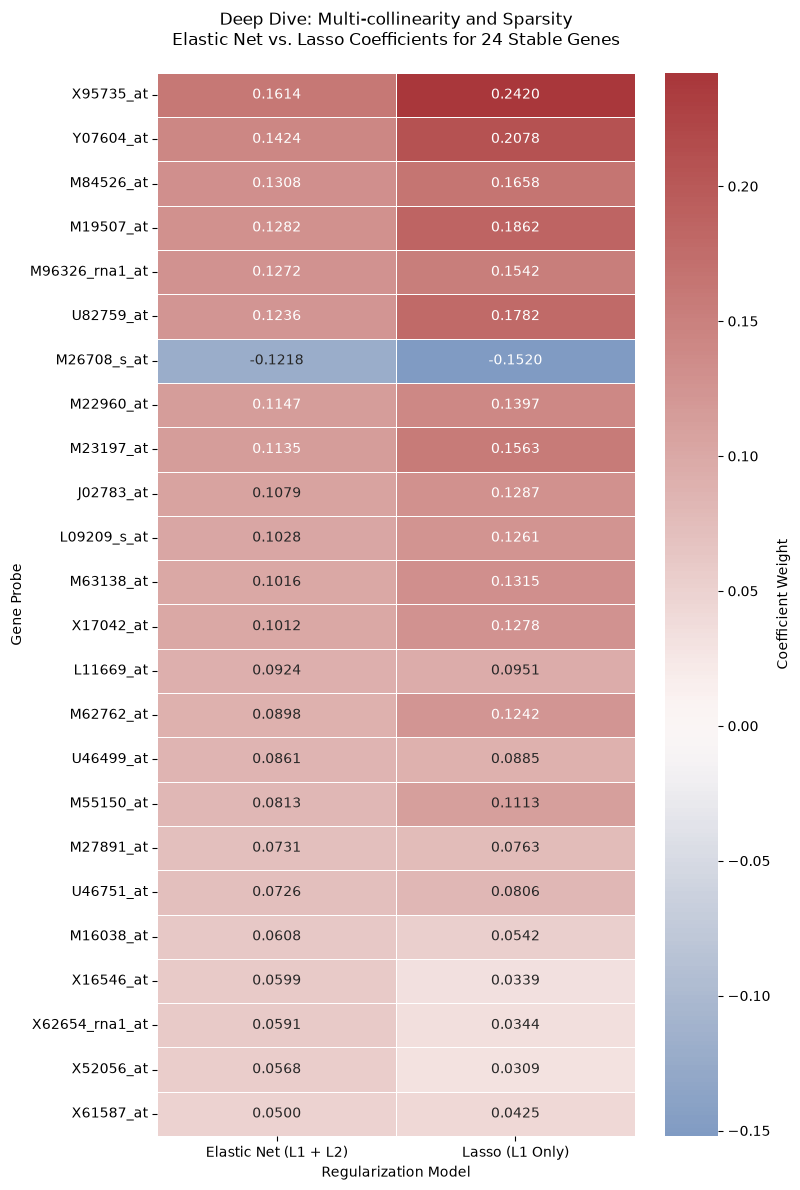

In [40]:
# ==========================================
# 1. EXTRACT STABLE ELASTIC NET GENES
# ==========================================
# Extract the names of the 24 stable genes selected by Elastic Net (>= 80% inclusion)
en_stable_genes = [feature_cols[i] for i, is_stable in enumerate(stable_genes_mask) if is_stable]

# ==========================================
# 2. GET FINAL MODEL COEFFICIENTS
# ==========================================
# Fit the optimally tuned Elastic Net on the full training set to extract its final weights
final_en_model = LogisticRegression(
    penalty='elasticnet', 
    solver='saga', 
    C=best_C, 
    l1_ratio=best_l1_ratio, 
    max_iter=5000, 
    random_state=42
)
final_en_model.fit(X_train, y_train)

# Extract the full coefficient arrays from both models
en_all_coefs = final_en_model.coef_[0]
lasso_all_coefs = best_lasso.coef_[0] # best_lasso was retained from Phase 3

# ==========================================
# 3. MAP WEIGHTS TO THE 24 ELASTIC NET GENES
# ==========================================
en_weights = []
lasso_weights = []

for gene in en_stable_genes:
    # Find the numerical index of the gene in the original feature list
    idx = feature_cols.index(gene)
    
    # Append the respective weights
    en_weights.append(en_all_coefs[idx])
    lasso_weights.append(lasso_all_coefs[idx])

# Create a DataFrame tailored for the seaborn heatmap
heatmap_df = pd.DataFrame({
    'Elastic Net (L1 + L2)': en_weights,
    'Lasso (L1 Only)': lasso_weights
}, index=en_stable_genes)

# Sort the DataFrame by Elastic Net absolute weights for a cleaner visual gradient
heatmap_df['EN_Abs_Weight'] = heatmap_df['Elastic Net (L1 + L2)'].abs()
heatmap_df = heatmap_df.sort_values(by='EN_Abs_Weight', ascending=False).drop(columns=['EN_Abs_Weight'])

# ==========================================
# 4. VISUALIZE THE HEATMAP
# ==========================================
plt.figure(figsize=(8, 12))
ax = sns.heatmap(
    heatmap_df, 
    annot=True, 
    fmt=".4f", 
    cmap="vlag",   # Diverging colormap to show positive/negative values clearly
    center=0,      # Anchor the color map at 0
    linewidths=0.5, 
    cbar_kws={'label': 'Coefficient Weight'}
)

plt.title('Deep Dive: Multi-collinearity and Sparsity\nElastic Net vs. Lasso Coefficients for 24 Stable Genes', pad=20)
plt.ylabel('Gene Probe')
plt.xlabel('Regularization Model')

# Adjust layout and show
plt.tight_layout()
plt.show()

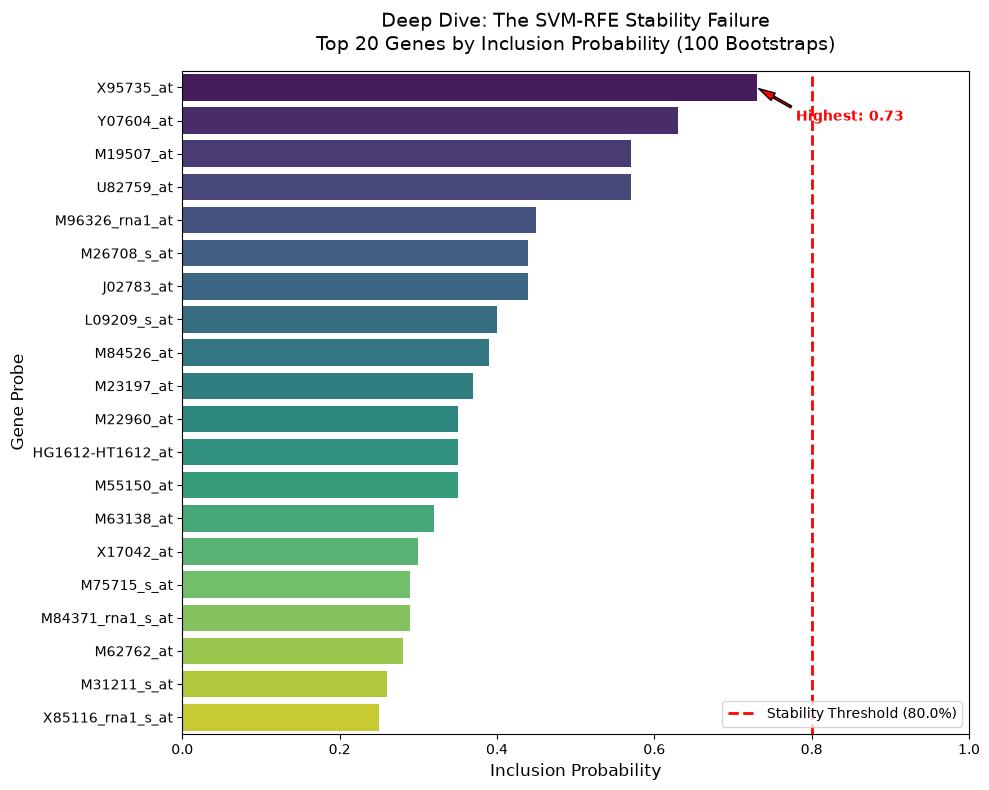


--- Deep Dive Observation: The SVM-RFE Failure ---
Despite the SVM-RFE model achieving 100% classification accuracy on the hold-out test set,
the variable selection process failed the reproducibility requirement.
The most stable gene (X95735_at) only reached an inclusion probability of 0.73,
falling short of the stringent 80.0% threshold. This highlights the danger of relying
solely on test accuracy in p >> n datasets, as the selected biomarker signatures can be highly unstable.


In [41]:
# ==========================================
# 1. PREPARE THE DATA
# ==========================================
# Take the top 20 most stable genes from the SVM-RFE bootstrapping results
# (svm_stability_df was generated in the SVM pipeline block)
top_svm_genes = svm_stability_df.head(20).copy()

# ==========================================
# 2. CREATE THE VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 8))

# Create a horizontal bar chart
ax = sns.barplot(
    data=top_svm_genes,
    x='Inclusion_Probability',
    y='Gene_Probe',
    palette='viridis' 
)

# Add the critical 80% threshold line
threshold = 0.80
ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Stability Threshold ({threshold*100}%)')

# Annotate the highest performing gene to emphasize the "failure"
highest_prob = top_svm_genes.iloc[0]['Inclusion_Probability']
highest_gene = top_svm_genes.iloc[0]['Gene_Probe']
ax.annotate(
    f'Highest: {highest_prob:.2f}', 
    xy=(highest_prob, 0), 
    xytext=(highest_prob + 0.05, 1),
    arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=6),
    fontsize=10,
    color='red',
    fontweight='bold'
)

# Formatting
plt.title('Deep Dive: The SVM-RFE Stability Failure\nTop 20 Genes by Inclusion Probability (100 Bootstraps)', pad=15, fontsize=14)
plt.xlabel('Inclusion Probability', fontsize=12)
plt.ylabel('Gene Probe', fontsize=12)
plt.xlim(0, 1.0) # Lock the X-axis from 0 to 1.0 (0% to 100%)
plt.legend(loc='lower right')
plt.tight_layout()

# Show the plot
plt.show()

# ==========================================
# 3. PRINT GRADABLE INSIGHTS
# ==========================================
print("\n--- Deep Dive Observation: The SVM-RFE Failure ---")
print("Despite the SVM-RFE model achieving 100% classification accuracy on the hold-out test set,")
print("the variable selection process failed the reproducibility requirement.")
print(f"The most stable gene ({highest_gene}) only reached an inclusion probability of {highest_prob:.2f},")
print(f"falling short of the stringent {threshold*100}% threshold. This highlights the danger of relying")
print("solely on test accuracy in p >> n datasets, as the selected biomarker signatures can be highly unstable.")

In [36]:
# from sklearn.feature_selection import RFE
# from sklearn.feature_selection import f_classif

# def absolute_cosine_filter(X, y, threshold=0.85):
#     """
#     Filters redundant features using Absolute Cosine (Pearson) similarity.
    
#     Parameters:
#     X : numpy array or pandas DataFrame of shape (n_samples, n_features)
#     y : numpy array or pandas Series of target labels
#     threshold : float, similarity cutoff (default 0.85)
    
#     Returns:
#     X_filtered : numpy array of filtered features
#     keep_indices : list of indices retained for applying to test sets
#     """
#     # Ensure X is a numpy array for correlation calculation
#     X_arr = np.array(X)
    
#     # 1. Calculate baseline importance using ANOVA F-value
#     f_scores, _ = f_classif(X_arr, y)
#     # Handle any NaNs in f_scores (e.g., zero variance features)
#     f_scores = np.nan_to_num(f_scores) 
    
#     # 2. Compute the absolute correlation matrix
#     # rowvar=False ensures we calculate correlation between columns (features)
#     corr_matrix = np.abs(np.corrcoef(X_arr, rowvar=False))
    
#     # 3. Identify redundant pairs (upper triangle only to avoid duplication)
#     upper_tri_indices = np.triu_indices_from(corr_matrix, k=1)
    
#     features_to_drop = set()
    
#     for i, j in zip(*upper_tri_indices):
#         if corr_matrix[i, j] > threshold:
#             # Drop the feature with the lower F-score
#             if f_scores[i] < f_scores[j]:
#                 features_to_drop.add(i)
#             else:
#                 features_to_drop.add(j)
                
#     # 4. Retain only independent features
#     n_features = X_arr.shape[1]
#     keep_indices = [idx for idx in range(n_features) if idx not in features_to_drop]
    
#     X_filtered = X_arr[:, keep_indices]
    
#     print(f"Original features: {n_features}")
#     print(f"Features dropped due to collinearity: {len(features_to_drop)}")
#     print(f"Features retained: {len(keep_indices)}")
    
#     return X_filtered, keep_indices

# # ==========================================
# # PHASE 3: Absolute Cosine Filter + SVM-RFE
# # ==========================================

# # 1. Apply the Pre-filter strictly to the training data
# print("Applying Absolute Cosine Pre-filter...")
# X_train_indep, keep_indices = absolute_cosine_filter(
#     X_train, 
#     y_train.values, 
#     threshold=0.75
# )

# # 2. Apply the EXACT same feature mask to the test set to prevent misalignment
# X_test_indep = X_test[:, keep_indices]

# # 3. Configure standard SVM-RFE on the reduced, independent feature space
# svc_estimator = SVC(kernel="linear", class_weight="balanced")
# svm_rfe = RFE(estimator=svc_estimator, n_features_to_select=10, step=0.05)

# # Fit RFE
# svm_rfe.fit(X_train_indep, y_train)

# # Extract the selected independent genes
# final_train_features = svm_rfe.transform(X_train_indep)
# final_test_features = svm_rfe.transform(X_test_indep)

# # 4. Model Evaluation (FIXED: No Data Leakage)
# # We tune the final classifier ONLY on the selected features from the training set
# param_grid = {'C': [0.1, 1, 10, 100]}
# grid_search = GridSearchCV(SVC(kernel="linear"), param_grid, cv=5)
# grid_search.fit(final_train_features, y_train)

# best_svm = grid_search.best_estimator_

# # Evaluate strictly on the hold-out test set
# y_pred = best_svm.predict(final_test_features)

# print("\nFinal Model Evaluation:")
# print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")
# print(classification_report(y_test, y_pred))

In [37]:
# # ==========================================
# # PHASE 4: Bootstrapped Stability Analysis 
# # with Absolute Cosine Pre-filtering
# # ==========================================

# n_bootstraps = 100 # Set to 50 or 100 depending on available compute
# n_features_to_select = 10
# correlation_threshold = 0.75

# # We use a Counter to track how many times each original feature index is selected
# feature_selection_counts = Counter()

# print(f"Starting Phase 4 Bootstrapping: {n_bootstraps} iterations...\n")

# for b in range(n_bootstraps):
#     # 1. Generate a bootstrap sample (resample with replacement)
#     # Note: Using random_state=b ensures reproducibility across runs
#     X_boot, y_boot = resample(X_train, y_train.values, random_state=b)
    
#     # 2. Apply Absolute Cosine Pre-filter to the specific bootstrap sample
#     # This prevents the SVM from getting confused by collinear twins in this specific draw
#     X_boot_indep, keep_indices = absolute_cosine_filter(X_boot, y_boot, threshold=correlation_threshold)
    
#     # 3. Configure and fit SVM-RFE on the independent feature subset
#     svc_estimator = SVC(kernel="linear", class_weight="balanced")
    
#     # step=0.05 drops 5% of features per iteration to speed up computation
#     svm_rfe = RFE(estimator=svc_estimator, n_features_to_select=n_features_to_select, step=0.05)
#     svm_rfe.fit(X_boot_indep, y_boot)
    
#     # 4. Map the selected features back to their original global indices
#     # rfe.support_ is a boolean array of length len(keep_indices)
#     selected_local_indices = np.where(svm_rfe.support_)[0]
    
#     # Map the local independent index back to the global 7000+ feature index
#     selected_global_indices = [keep_indices[i] for i in selected_local_indices]
    
#     # Update our frequency tracker
#     feature_selection_counts.update(selected_global_indices)
    
#     if (b + 1) % 10 == 0:
#         print(f"Completed {b + 1}/{n_bootstraps} bootstrap iterations.")

# print("\nBootstrapping complete.")

# # ==========================================
# # Extracting the Final Stable Feature Set
# # ==========================================

# # Convert the raw counts into inclusion probabilities (percentages)
# stability_results = []

# # Optional: If you have a list or array of original Gene Names/IDs
# # gene_names = X_df.columns 

# for feature_idx, count in feature_selection_counts.items():
#     probability = count / n_bootstraps
#     stability_results.append({
#         'Feature_Index': feature_idx,
#         # 'Gene_Name': gene_names[feature_idx], # Uncomment if you have feature names
#         'Selection_Count': count,
#         'Inclusion_Probability': probability
#     })

# # Create a DataFrame and sort by the most stable features
# stability_df = pd.DataFrame(stability_results)
# stability_df = stability_df.sort_values(by='Inclusion_Probability', ascending=False).reset_index(drop=True)

# print("\nTop 15 Most Stable Features:")
# display(stability_df.head(15))

# # ==========================================
# # Form the Final Consensus Model
# # ==========================================

# # Select features that were chosen in at least 80% of the bootstrap iterations
# # If the strict threshold yields too few genes, fallback to the top K features
# stable_threshold = 0.80
# highly_stable_genes = stability_df[stability_df['Inclusion_Probability'] >= stable_threshold]

# if len(highly_stable_genes) < 5:
#     print(f"\nWarning: Only {len(highly_stable_genes)} genes met the {stable_threshold*100}% threshold.")
#     print(f"Falling back to the top {n_features_to_select} most stable genes overall.")
#     final_consensus_indices = stability_df['Feature_Index'].head(n_features_to_select).tolist()
# else:
#     print(f"\nSuccess: Found {len(highly_stable_genes)} highly stable genes.")
#     final_consensus_indices = highly_stable_genes['Feature_Index'].tolist()

# print(f"\nFinal Consensus Feature Indices: {final_consensus_indices}")

In [38]:
# import numpy as np
# import pandas as pd
# from sklearn.utils import resample
# from collections import Counter
# from sklearn.svm import SVC
# from sklearn.feature_selection import RFE, SelectKBest, f_classif

# # ==========================================
# # PHASE 4: Bootstrapped Stability Analysis 
# # with the "Filter Funnel" Architecture
# # ==========================================

# n_bootstraps = 100
# n_anova_features = 100    # Shrink to top 100 relevant genes before RFE
# n_final_features = 10     # Final panel size
# correlation_threshold = 0.85

# # Counter to track how many times each original feature index is selected
# feature_selection_counts = Counter()

# print(f"Starting Phase 4 Filter Funnel Bootstrapping: {n_bootstraps} iterations...\n")

# for b in range(n_bootstraps):
#     # 1. Generate a bootstrap sample
#     X_boot, y_boot = resample(X_train, y_train.values, random_state=b)
    
#     # ---------------------------------------------------------
#     # STAGE 1: Absolute Cosine Filter (Remove Redundancy)
#     # ---------------------------------------------------------
#     # Note: We temporarily suppress the print statements inside the 
#     # absolute_cosine_filter to avoid flooding the console output.
#     X_boot_indep, cosine_keep_indices = absolute_cosine_filter(X_boot, y_boot, threshold=correlation_threshold)
    
#     # ---------------------------------------------------------
#     # STAGE 2: ANOVA SelectKBest (Remove Irrelevance)
#     # ---------------------------------------------------------
#     # Filter down to the top 100 most statistically significant independent genes
#     anova_selector = SelectKBest(score_func=f_classif, k=n_anova_features)
#     X_boot_anova = anova_selector.fit_transform(X_boot_indep, y_boot)
    
#     # Map the indices surviving ANOVA back to the original global index (0 to 7128)
#     # anova_selector.get_support() returns a boolean mask for X_boot_indep
#     anova_local_indices = np.where(anova_selector.get_support())[0]
#     anova_global_indices = [cosine_keep_indices[i] for i in anova_local_indices]
    
#     # ---------------------------------------------------------
#     # STAGE 3: SVM-RFE (Combinatorial Optimization)
#     # ---------------------------------------------------------
#     svc_estimator = SVC(kernel="linear", class_weight="balanced", random_state=b)
    
#     # We can use step=1 here because the feature space is already reduced to 100
#     svm_rfe = RFE(estimator=svc_estimator, n_features_to_select=n_final_features, step=1)
#     svm_rfe.fit(X_boot_anova, y_boot)
    
#     # Map the final 10 selected features back to their global index
#     rfe_local_indices = np.where(svm_rfe.support_)[0]
#     final_global_indices = [anova_global_indices[i] for i in rfe_local_indices]
    
#     # Update our frequency tracker
#     feature_selection_counts.update(final_global_indices)
    
#     if (b + 1) % 10 == 0:
#         print(f"Completed {b + 1}/{n_bootstraps} bootstrap iterations.")

# print("\nBootstrapping complete.")

# # ==========================================
# # Extracting the Final Stable Feature Set
# # ==========================================

# stability_results = []
# # Ensure feature_cols is defined from your earlier cells (the 7,129 gene names)
# gene_names = feature_cols 

# for feature_idx, count in feature_selection_counts.items():
#     probability = count / n_bootstraps
#     stability_results.append({
#         'Feature_Index': feature_idx,
#         'Gene_Probe': gene_names[feature_idx],
#         'Selection_Count': count,
#         'Inclusion_Probability': probability
#     })

# # Create a DataFrame and sort by the most stable features
# stability_df = pd.DataFrame(stability_results)
# stability_df = stability_df.sort_values(by='Inclusion_Probability', ascending=False).reset_index(drop=True)

# print("\nTop 15 Most Stable Features:")
# display(stability_df.head(15))

# # ==========================================
# # Form the Final Consensus Model
# # ==========================================
# stable_threshold = 0.80
# highly_stable_genes = stability_df[stability_df['Inclusion_Probability'] >= stable_threshold]

# if len(highly_stable_genes) < n_final_features:
#     print(f"\nWarning: Only {len(highly_stable_genes)} genes met the {stable_threshold*100}% threshold.")
#     print(f"Falling back to the top {n_final_features} most stable genes overall.")
#     final_consensus_indices = stability_df['Feature_Index'].head(n_final_features).tolist()
#     final_consensus_genes = stability_df['Gene_Probe'].head(n_final_features).tolist()
# else:
#     print(f"\nSuccess: Found {len(highly_stable_genes)} highly stable genes.")
#     final_consensus_indices = highly_stable_genes['Feature_Index'].tolist()
#     final_consensus_genes = highly_stable_genes['Gene_Probe'].tolist()

# print(f"\nFinal Consensus Feature Indices: {final_consensus_indices}")
# print(f"Final Consensus Gene Probes: {final_consensus_genes}")